## Data-analyse dag 3

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

from lmfit import models

### Data from measurements

In [7]:
dist_noz = [5.6,5.6,5.6,6.6,6.6,6.6,7.6,7.6,7.6,8.6,8.6,8.6,9.6,9.6,9.6,]
med_vol = [185.309967041,233.603973389,248.303009033,168.871261597,182.77796936,227.372680664,213.433013916,205.360137939,159.382064819,179.57963562,228.407089233,220.441680908,178.961242676,225.229476929,207.024429321]


print(len(dist_noz),len(med_vol))

15 15


## Faults

In [8]:
err_dist_noz = [0.2]*15
err_med_vol = [18.6572856903,33.7856254578,54.365020752, 8.93819904327,18.123085022,36.7641181946,26.54155159,21.3621444702,8.58355808258,13.638338089,25.2518672943,23.2559738159,16.7435188293,28.5867786407,25.8330287933]


print(len(err_dist_noz),len(err_med_vol))

15 15


## Plots of first measurement

Text(0, 0.5, 'Median droplet volume')

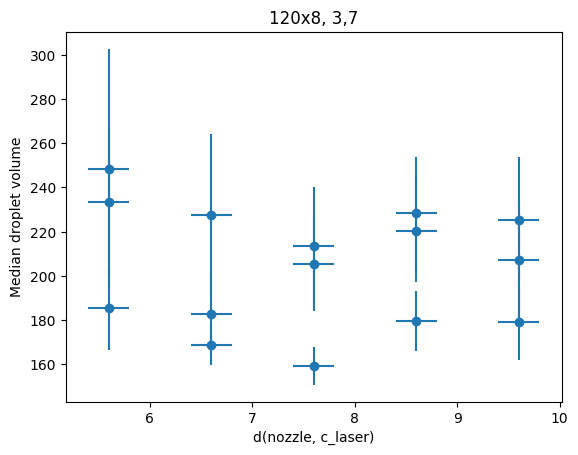

In [9]:
plt.figure()

plt.errorbar(dist_noz, med_vol, xerr=err_dist_noz, yerr=err_med_vol, fmt='o')

plt.title(r"120x8, 3,7")
plt.xlabel(r"d(nozzle, c_laser)")
plt.ylabel(r"Median droplet volume")

## Fitfunction

In [28]:
def fit_function(x_fit, p1, p2, ):
    med_vol = p1 * x_fit + p2  
    return med_vol

In [29]:
fit_model = models.Model(fit_function)

In [30]:
err_med_vol_array = np.array(err_med_vol)
err_med_vol_inv = 1 / err_med_vol_array

In [31]:
fit_result = fit_model.fit(med_vol, x_fit=np.array(dist_noz), weights=err_med_vol_inv, p1=1.5, p2=1.5)

Text(0, 0.5, 'Median volume of droplets')

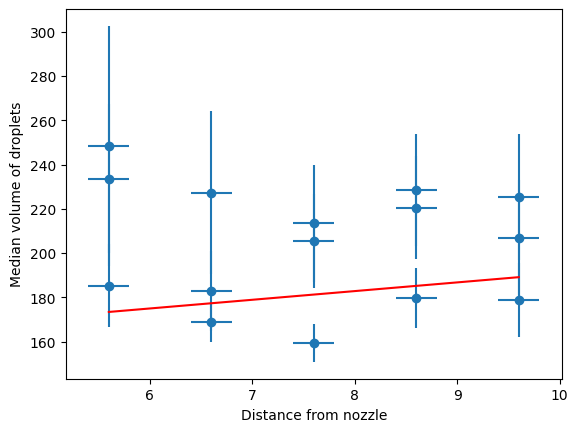

In [32]:
plt.figure()

plt.errorbar(dist_noz, med_vol, xerr=err_dist_noz, yerr=err_med_vol, fmt='o')
plt.plot(dist_noz, fit_result.best_fit, 'r-')

plt.xlabel(r'Distance from nozzle')
plt.ylabel(r'Median volume of droplets')

In [33]:
print(fit_result.fit_report())

[[Model]]
    Model(fit_function)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 15
    # variables        = 2
    chi-square         = 25.3984424
    reduced chi-square = 1.95372634
    Akaike info crit   = 11.8995647
    Bayesian info crit = 13.3156651
    R-squared          = -0.88653699
[[Variables]]
    p1:  3.92947807 +/- 5.42363803 (138.02%) (init = 1.5)
    p2:  151.379717 +/- 41.3510305 (27.32%) (init = 1.5)
[[Correlations]] (unreported correlations are < 0.100)
    C(p1, p2) = -0.9891
